# Datos Faltantes

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [4]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [5]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
375,0.045341,0.050680,-0.002973,0.107944,0.035582,0.022485,0.026550,-0.002592,0.028020,0.019633,217.0
369,-0.009147,-0.044642,0.037984,-0.040099,-0.024960,-0.003819,-0.043401,0.015858,-0.005142,0.027917,167.0
151,0.001751,-0.044642,-0.004050,-0.005670,-0.008449,-0.023861,0.052322,-0.039493,-0.008943,-0.013504,88.0
330,0.009016,0.050680,0.030440,0.042529,-0.002945,0.036890,-0.065491,0.071210,-0.023647,0.015491,244.0
227,0.067136,0.050680,-0.029918,0.057437,-0.000193,-0.015719,0.074412,-0.050564,-0.038460,0.007207,108.0
255,0.001751,-0.044642,-0.065486,-0.005670,-0.007073,-0.019476,0.041277,-0.039493,-0.003301,0.007207,153.0
322,0.023546,0.050680,0.061696,0.062050,0.024574,-0.036073,-0.091262,0.155345,0.133397,0.081764,242.0
20,-0.049105,-0.044642,-0.056863,-0.043542,-0.045599,-0.043276,0.000779,-0.039493,-0.011897,0.015491,68.0
84,0.001751,-0.044642,-0.039618,-0.100934,-0.029088,-0.030124,0.044958,-0.050195,-0.068332,-0.129483,65.0
86,-0.070900,0.050680,-0.075186,-0.040099,-0.051103,-0.015092,-0.039719,-0.002592,-0.096435,-0.034215,55.0


In [6]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [7]:
missing_values = data.isnull().sum()

print("Valores faltantes por columna:")

print(missing_values)

Valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [11]:

data_simple = data.copy()

imputer = SimpleImputer(strategy='mean')

data_simple[['bmi']] = imputer.fit_transform(data_simple[['bmi']])

print("Valores faltantes después de imputar:")
print(data_simple['bmi'].isnull().sum())

Valores faltantes después de imputar:
0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:

data_knn = data.copy()
knn = KNNImputer(n_neighbors=5)
data_knn[['bmi','bp']] = knn.fit_transform(data_knn[['bmi','bp']])

print("Valores faltantes después de KNN:")
print(data_knn[['bmi','bp']].isnull().sum())

Valores faltantes después de KNN:
bmi    0
bp     0
dtype: int64


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

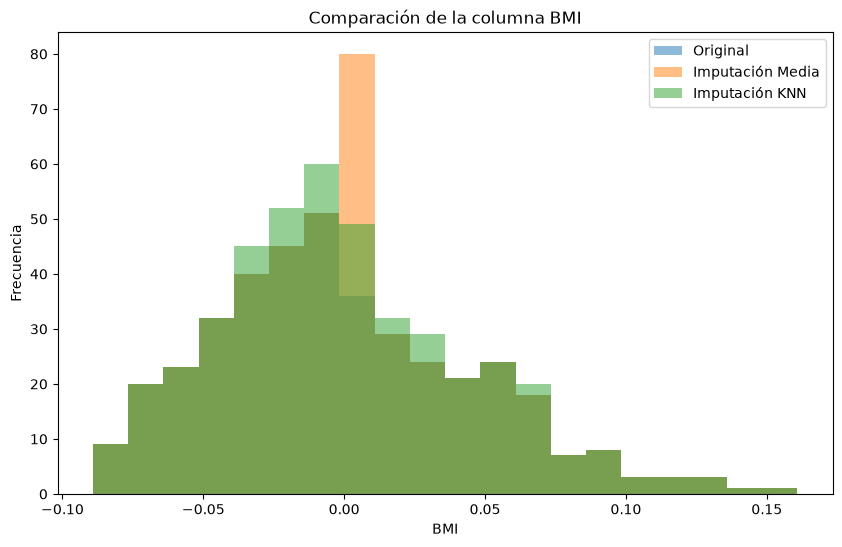

In [10]:
plt.figure(figsize=(10,6))

# Datos originales (sin NaN)
plt.hist(
    data['bmi'].dropna(),
    bins=20,
    alpha=0.5,
    label='Original'
)

# Imputación simple
plt.hist(
    data_simple['bmi'],
    bins=20,
    alpha=0.5,
    label='Imputación Media'
)

# Imputación KNN
plt.hist(
    data_knn['bmi'],
    bins=20,
    alpha=0.5,
    label='Imputación KNN'
)

plt.title("Comparación de la columna BMI")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()